In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

## task 1

In [2]:
eq=pd.read_csv("C:\\Users\\andrz\\Downloads\\earthquake.txt",sep=' ')

In [7]:
eq

,popn,body,surface
0,equake,5.60,4.25
1,equake,5.18,3.93
2,equake,6.31,6.30
3,equake,5.36,4.49
4,equake,5.96,6.39
5,equake,5.26,4.42
6,equake,5.17,5.10
7,equake,4.75,4.40
8,equake,5.35,5.49
9,equake,5.01,4.48


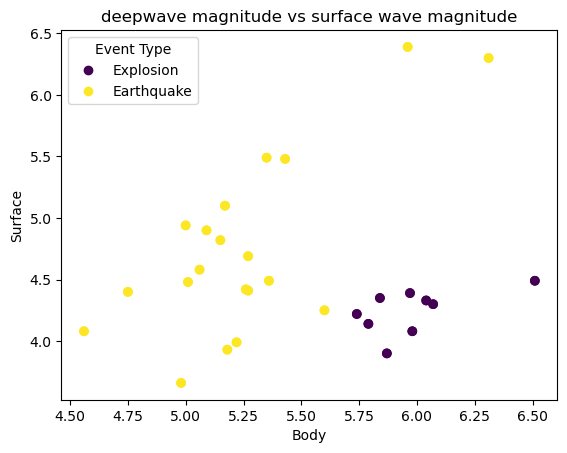

In [3]:
colors=np.zeros(len(eq))
for i in range(len(eq)):
    if eq.iloc[i,0]=="equake":
        colors[i]=1
plt.scatter(eq.iloc[:,1],eq.iloc[:,2],c=colors)
scatter = plt.scatter(eq.iloc[:, 1], eq.iloc[:, 2], c=colors)
handles, labels = scatter.legend_elements()
plt.legend(handles, ["Explosion", "Earthquake"], title="Event Type")
plt.title('deepwave magnitude vs surface wave magnitude')
plt.xlabel('Body')
plt.ylabel('Surface')
plt.show()

In [4]:
X=eq.iloc[:,1:3]
y=eq.iloc[:,0]

In [5]:
unreglog=LogisticRegression(penalty=None)
unreglog.fit(X,colors)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
print(unreglog.coef_)

[[-111.91608035  117.54515973]]


In [8]:
reglog=LogisticRegression()
reglog.fit(X,colors)
print(reglog.coef_)

[[-2.16922885  1.18171354]]


C:\Users\andrz\anaconda3\envs\workspace\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\andrz\anaconda3\envs\workspace\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


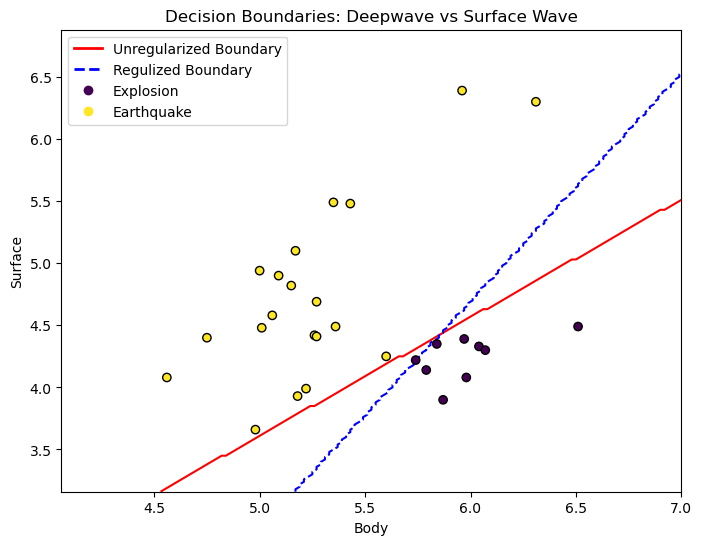

In [9]:


# 1. Create a mesh grid to cover the plot area
x_min, x_max = eq.iloc[:, 1].min() - 0.5, eq.iloc[:, 1].max() + 0.5
y_min, y_max = eq.iloc[:, 2].min() - 0.5, eq.iloc[:, 2].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 2. Predict across the grid for both models
# We use .predict() to get the boundary line
Z_unreg = unreglog.predict(np.c_[xx.ravel(), yy.ravel()])
Z_unreg = Z_unreg.reshape(xx.shape)

Z_reg = reglog.predict(np.c_[xx.ravel(), yy.ravel()])
Z_reg = Z_reg.reshape(xx.shape)

# 3. Plotting
plt.figure(figsize=(8, 6))

# Plot the original scatter points
scatter = plt.scatter(eq.iloc[:, 1], eq.iloc[:, 2], c=colors, edgecolors='k', zorder=3)

# Add the Unregularized boundary (Solid line)
cont_unreg = plt.contour(xx, yy, Z_unreg, levels=[0.5], colors='red', linestyles='solid')
# Add the Regularized boundary (Dashed line)
cont_reg = plt.contour(xx, yy, Z_reg, levels=[0.5], colors='blue', linestyles='dashed')

# Create custom legend for the lines
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Unregularized (None)'),
    Line2D([0], [0], color='blue', lw=2, linestyle='--', label='Regularized (L2)'),
    scatter.legend_elements()[0][0], # Green dot
    scatter.legend_elements()[0][1]  # Yellow dot
]

plt.legend(handles=legend_elements, labels=['Unregularized Boundary', 'Regulized Boundary', 'Explosion', 'Earthquake'])

plt.title('Decision Boundaries: Deepwave vs Surface Wave')
plt.xlabel('Body')
plt.ylabel('Surface')
plt.show()

## task 2

In [13]:
def generate_logistic(n):
    x1=np.random.normal(0,1,n)
    x2=np.random.normal(0,1,n)
    x3=np.random.normal(0,1,n)
    x4=np.random.normal(0,1,n)
    x5=np.random.normal(0,1,n)
    p=1/(1+np.exp(-1*(0.5+x1+x2+x3+x4+x5)))
    y=np.random.binomial(1,p,n)
    X=np.array([x1,x2,x3,x4,x5])
    X=X.T
    return X,y
def calc_euclidean_distance(x,y):
    if len(x)!=len(y):
        raise ValueError("The two arrays must have the same length")
    d=0
    for i in range(len(x)):
        d+=(x[i]-y[i])**2
    return np.sqrt(d)
def experiment_singular(n,true_coef,selected_features=None,printcoef=False):
    X,y=generate_logistic(n)
    true_coef_used=true_coef.copy()
    if selected_features is not None:
        true_coef_used=true_coef_used[selected_features]
        X=X[:,selected_features]
    logreg=LogisticRegression()
    logreg.fit(X,y)
    if printcoef:
        print(logreg.coef_)
    return calc_euclidean_distance(logreg.coef_[0],true_coef_used)**2
def experiment_multiple(L,n,true_coef,selected_features=None,printcoef=False):
    mse_singles=np.zeros(L)
    for i in range(L):
        mse_singles[i]=experiment_singular(n,true_coef,selected_features,printcoef)
    return np.mean(mse_singles)




In [10]:
true_coef=np.array([1,1,1,1,1])


In [9]:
print(experiment_multiple(100,50,true_coef))

0.7907167849887794


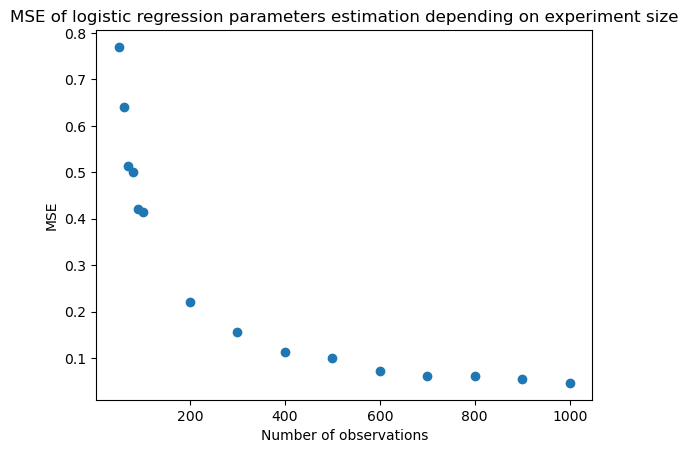

In [10]:
n_s=[50,60,70,80,90,100,200,300,400,500,600,700,800,900,1000]
mse_estimators=np.zeros(len(n_s))
for i in range(len(n_s)):
    mse_estimators[i]=experiment_multiple(100,n_s[i],true_coef)
plt.scatter(n_s,mse_estimators)
plt.title("MSE of logistic regression parameters estimation depending on experiment size")
plt.xlabel('Number of observations')
plt.ylabel('MSE')
plt.show()

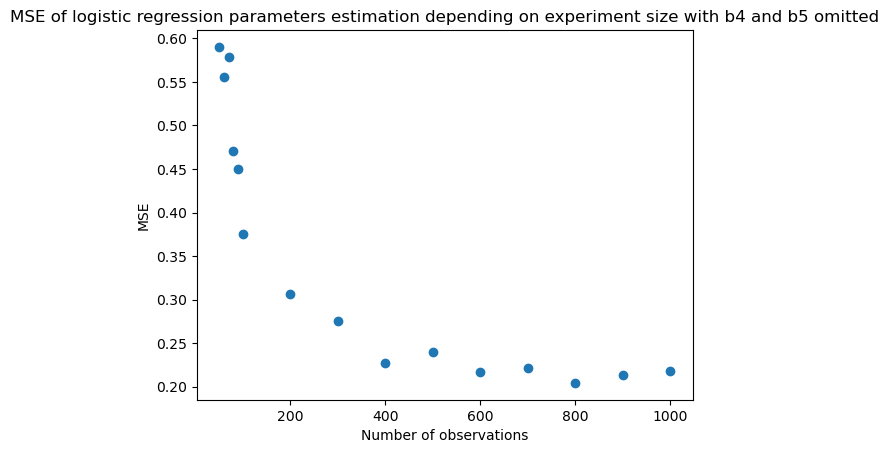

In [14]:
n_s=[50,60,70,80,90,100,200,300,400,500,600,700,800,900,1000]
mse_estimators=np.zeros(len(n_s))
for i in range(len(n_s)):
    mse_estimators[i]=experiment_multiple(100,n_s[i],true_coef,selected_features=[0,1,2])
plt.scatter(n_s,mse_estimators)
plt.title("MSE of logistic regression parameters estimation depending on experiment size with b4 and b5 omitted")
plt.xlabel('Number of observations')
plt.ylabel('MSE')
plt.show()

# Comment on both approaches
 - When training the logistic model with all features the decrease in MSE when there are more observations is stable, with MSE at small sample (50) being high (ca. 0.8), but at bigger samples (800-1000) much smaller at less than 0.1 . It is clear that after 400-500 obs. the effect of having more is much lower than with smaller samples.
- When training the logistic model with not all features used the decrease in MSE when there are more observations is also observable at the begining, but it is not as stable as in case of the model using all features. At the beginning the MSE is lower than in the previous approach (at ca. 0.6) but it only decreases to ca. 0.2-0.25 and with more samples there is sometimes decrease and sometimes increase of MSE.